##**Importing all necessary libraries**

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

!pip install lifetimes
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from lifetimes.utils import summary_data_from_transaction_data


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 13.0 MB/s eta 0:00:00


##**Setting visualization style**

In [3]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100


##**Loading the cleaned transaction data**

In [4]:

# Load the cleaned transaction data
# transactions = pd.read_csv('data/processed/online_retail_cleaned.csv')


from google.colab import files
from google.colab import drive
drive.mount('/content/drive')


uploaded = files.upload()
transactions = pd.read_csv('online_retail_cleaned.csv')
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])


Mounted at /content/drive


Saving online_retail_cleaned.csv to online_retail_cleaned.csv


##**Loading the churn predictions**

In [8]:

from google.colab import files
from google.colab import drive
drive.mount('/content/drive')


uploaded = files.upload()
customer_clusters = pd.read_csv('customer_clusters.csv')

# Load the customer clusters and churn predictions
# customer_clusters = pd.read_csv('data/processed/customer_clusters.csv')
churn_predictions = pd.read_csv('churn_prediction.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving churn_prediction.csv to churn_prediction.csv


##**Defining the observation period end date**

In [9]:
# Define the observation period end date
observation_end = transactions['InvoiceDate'].max()
print(f"Observation period end: {observation_end}")

Observation period end: 2011-12-09 12:50:00


##**Preparing data for the BG/NBD model (frequency and recency)**

In [12]:
 #Prepare data for the BG/NBD model (frequency and recency)
# What are needed: frequency, recency, T (customer age) and monetary value
# First, creating the RFM summary
rfm_lifetimes = summary_data_from_transaction_data(
    transactions,
    'Customer ID',
    'InvoiceDate',
    'TotalAmount',
    observation_period_end=observation_end
)

print(f"RFM summary shape: {rfm_lifetimes.shape}")
print("\nRFM summary statistics:")
display(rfm_lifetimes.head())
display(rfm_lifetimes.describe())

RFM summary shape: (4290, 4)

RFM summary statistics:


,frequency,recency,T,monetary_value
Customer ID,,,,
12347.0,6.0,365.0,367.0,558.101667
12348.0,3.0,283.0,358.0,205.800000
12349.0,0.0,0.0,18.0,0.000000
12350.0,0.0,0.0,310.0,0.000000
12352.0,6.0,260.0,296.0,181.540000


,frequency,recency,T,monetary_value
count,4290.000000,4290.000000,4290.000000,4290.000000
mean,2.818648,130.332401,222.431235,235.435097
std,5.859092,132.148775,117.725503,329.490574
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,112.000000,0.000000
50%,1.000000,91.000000,248.000000,168.508333
75%,3.000000,252.000000,326.000000,342.740089
max,129.000000,373.000000,373.000000,4860.857692


##**Checking for any issues in the RFM summary**

In [13]:
# Check for any issues in the RFM summary
print(f"\nCustomers with frequency=0: {(rfm_lifetimes['frequency'] == 0).sum()}")
print(f"Customers with monetary_value=0: {(rfm_lifetimes['monetary_value'] == 0).sum()}")

# Remove any problematic rows
rfm_lifetimes = rfm_lifetimes[rfm_lifetimes['monetary_value'] > 0]
print(f"Clean RFM summary shape: {rfm_lifetimes.shape}")

# Fit the BG/NBD model (for purchase frequency)
print("\nFitting BG/NBD model...")
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm_lifetimes['frequency'], rfm_lifetimes['recency'], rfm_lifetimes['T'])
print("BG/NBD model fit successful")

# Print model parameters
print("\nBG/NBD model parameters:")
print(f"r: {bgf.params_['r']:.4f}")
print(f"alpha: {bgf.params_['alpha']:.4f}")
print(f"a: {bgf.params_['a']:.4f}")
print(f"b: {bgf.params_['b']:.4f}")



Customers with frequency=0: 1546
Customers with monetary_value=0: 1546
Clean RFM summary shape: (2744, 4)

Fitting BG/NBD model...
BG/NBD model fit successful

BG/NBD model parameters:
r: 1.6157
alpha: 91.8228
a: 0.0054
b: 0.1154


##**Visualizing frequency/recency matrix**

/usr/local/lib/python3.11/dist-packages/autograd/tracer.py:48: RuntimeWarning: invalid value encountered in log
  return f_raw(*args, **kwargs)


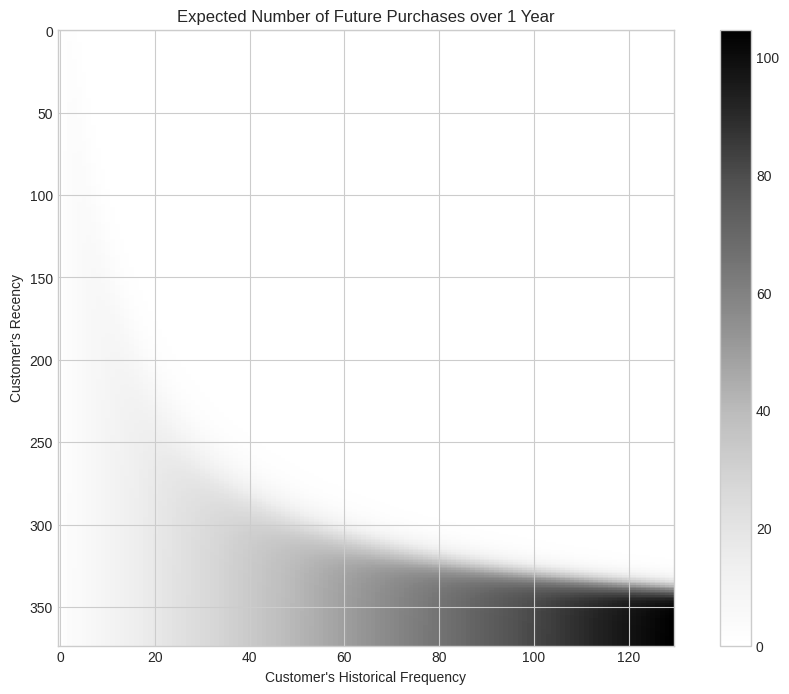

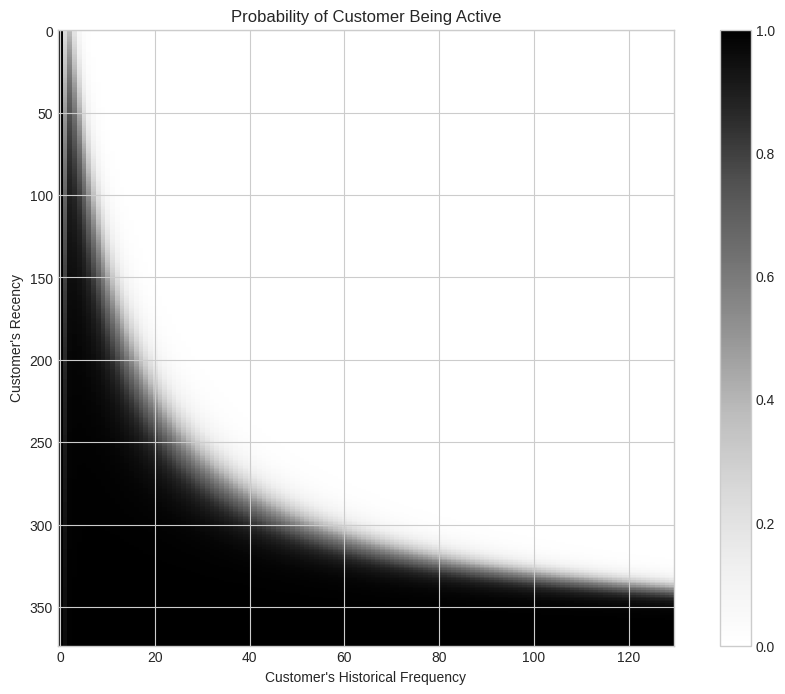


Fitting Gamma-Gamma model...
Gamma-Gamma model fit successful

Gamma-Gamma model parameters:
p: 3.7691
q: 0.3427
v: 3.6628


In [14]:
# Visualize frequency/recency matrix
plt.figure(figsize=(12, 8))
plot_frequency_recency_matrix(bgf, T=rfm_lifetimes['T'].max())
plt.title('Expected Number of Future Purchases over 1 Year')
plt.show()

# Visualize probability alive matrix
plt.figure(figsize=(12, 8))
plot_probability_alive_matrix(bgf)
plt.title('Probability of Customer Being Active')
plt.show()

# Predict purchases for the next periods
t = 12  # predict for 12 months
predicted_purchases = bgf.predict(t, rfm_lifetimes['frequency'], rfm_lifetimes['recency'], rfm_lifetimes['T'])

# Add predictions to the RFM summary
rfm_lifetimes['predicted_purchases'] = predicted_purchases

# Fit the Gamma-Gamma model (for monetary value)
print("\nFitting Gamma-Gamma model...")
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(rfm_lifetimes['frequency'], rfm_lifetimes['monetary_value'])
print("Gamma-Gamma model fit successful")

# Print model parameters
print("\nGamma-Gamma model parameters:")
print(f"p: {ggf.params_['p']:.4f}")
print(f"q: {ggf.params_['q']:.4f}")
print(f"v: {ggf.params_['v']:.4f}")

##**Calculating expected average profit**


Customer Lifetime Value (12 months) Statistics:


,CLV_12_months
count,2744.000000
mean,2398.236284
std,4884.735807
min,13.164635
25%,752.167946
50%,1437.868147
75%,2682.933713
max,125518.572731


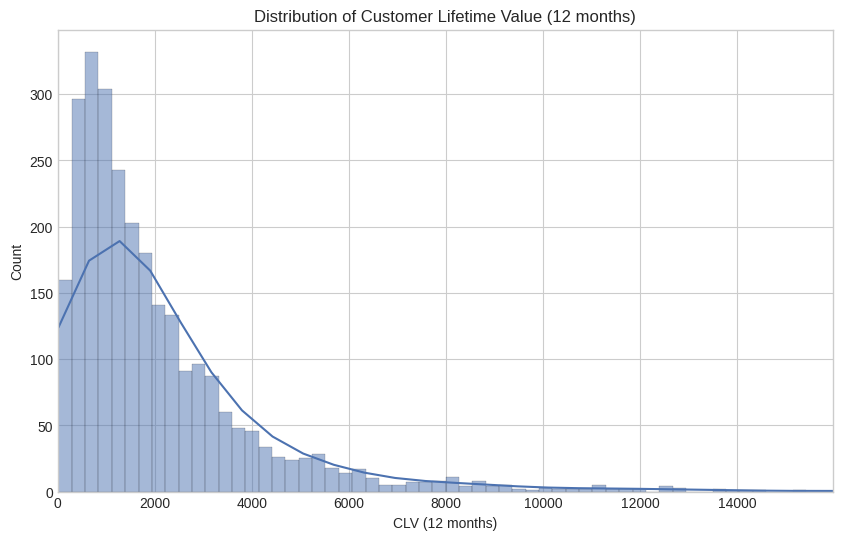

In [15]:
 #Calculate expected average profit
expected_average_profit = ggf.conditional_expected_average_profit(
    rfm_lifetimes['frequency'],
    rfm_lifetimes['monetary_value']
)

rfm_lifetimes['expected_average_profit'] = expected_average_profit

# Calculate customer lifetime value for 12 months
clv = ggf.customer_lifetime_value(
    bgf,
    rfm_lifetimes['frequency'],
    rfm_lifetimes['recency'],
    rfm_lifetimes['T'],
    rfm_lifetimes['monetary_value'],
    time=12,  # months
    discount_rate=0.01  # monthly discount rate ~ 12.7% annually
)

rfm_lifetimes['CLV_12_months'] = clv

# Display CLV summary statistics
print("\nCustomer Lifetime Value (12 months) Statistics:")
display(rfm_lifetimes['CLV_12_months'].describe())

# Visualize CLV distribution
plt.figure(figsize=(10, 6))
sns.histplot(rfm_lifetimes['CLV_12_months'], kde=True)
plt.title('Distribution of Customer Lifetime Value (12 months)')
plt.xlabel('CLV (12 months)')
plt.xlim(0, rfm_lifetimes['CLV_12_months'].quantile(0.99))  # Limit x-axis to 99th percentile
plt.show()

In [21]:
## Add customer ID as index to join with other data
# Check if 'level_0' column already exists
if 'level_0' not in rfm_lifetimes.columns:
    rfm_lifetimes = rfm_lifetimes.reset_index()
else:
    print("The dataframe already contains a column named 'level_0'. Skipping reset_index().")

# Merge CLV data with customer clusters and churn predictions
customer_data = rfm_lifetimes.merge(customer_clusters[['Customer ID', 'Cluster', 'Cluster_Name']],
                                    on='Customer ID', how='left')
customer_data = customer_data.merge(churn_predictions[['Customer ID', 'ChurnProbability', 'ValueSegment']],
                                   on='Customer ID', how='left')

# Calculate CLV adjusted for churn probability
customer_data['Adjusted_CLV'] = customer_data['CLV_12_months'] * (1 - customer_data['ChurnProbability'])

# Analyze CLV by customer segment
clv_by_segment = customer_data.groupby('Cluster_Name').agg({
    'CLV_12_months': ['mean', 'sum'],
    'Adjusted_CLV': ['mean', 'sum'],
    'Customer ID': 'count'
}).reset_index()

clv_by_segment.columns = ['Cluster_Name', 'Avg_CLV', 'Total_CLV', 'Avg_Adjusted_CLV', 'Total_Adjusted_CLV', 'CustomerCount']
clv_by_segment['Segment_Value_Percentage'] = clv_by_segment['Total_Adjusted_CLV'] / clv_by_segment['Total_Adjusted_CLV'].sum() * 100
clv_by_segment = clv_by_segment.sort_values('Total_Adjusted_CLV', ascending=False)

print("\nCLV by Customer Segment:")
display(clv_by_segment)

The dataframe already contains a column named 'level_0'. Skipping reset_index().

CLV by Customer Segment:


,Cluster_Name,Avg_CLV,Total_CLV,Avg_Adjusted_CLV,Total_Adjusted_CLV,CustomerCount,Segment_Value_Percentage
1,Inactive Customers,1704.231035,4.279324e+06,1238.829298,3.110700e+06,2511,57.770696
0,High-Value Active Customers,9877.408725,2.301436e+06,9759.073527,2.273864e+06,233,42.229304


##**Visualizing Customer Lifetime Value by segment**

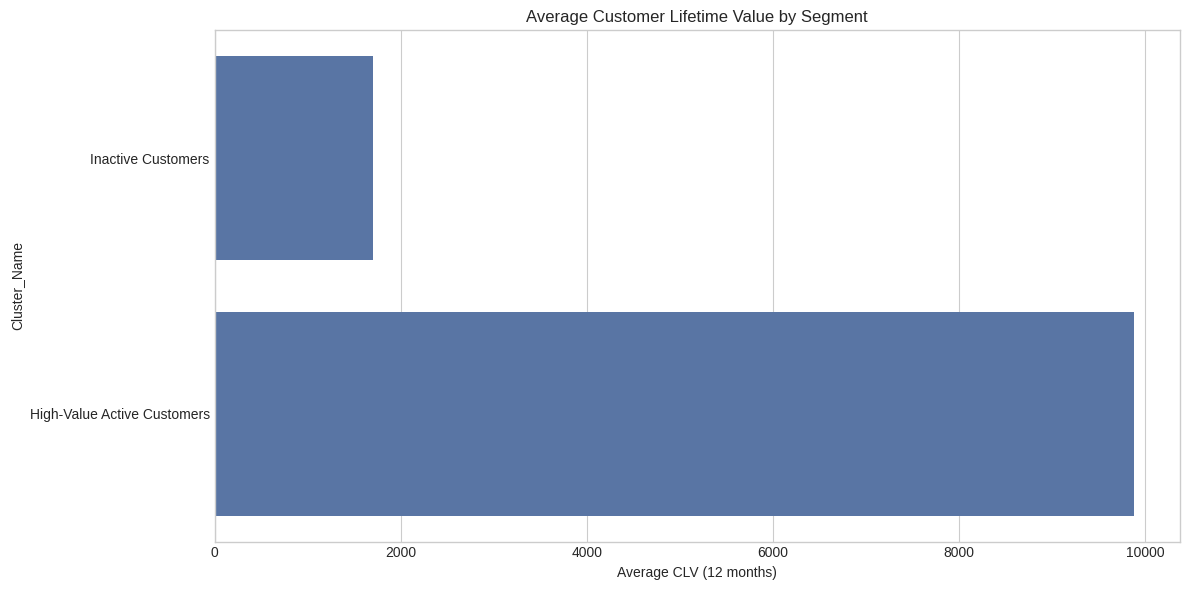

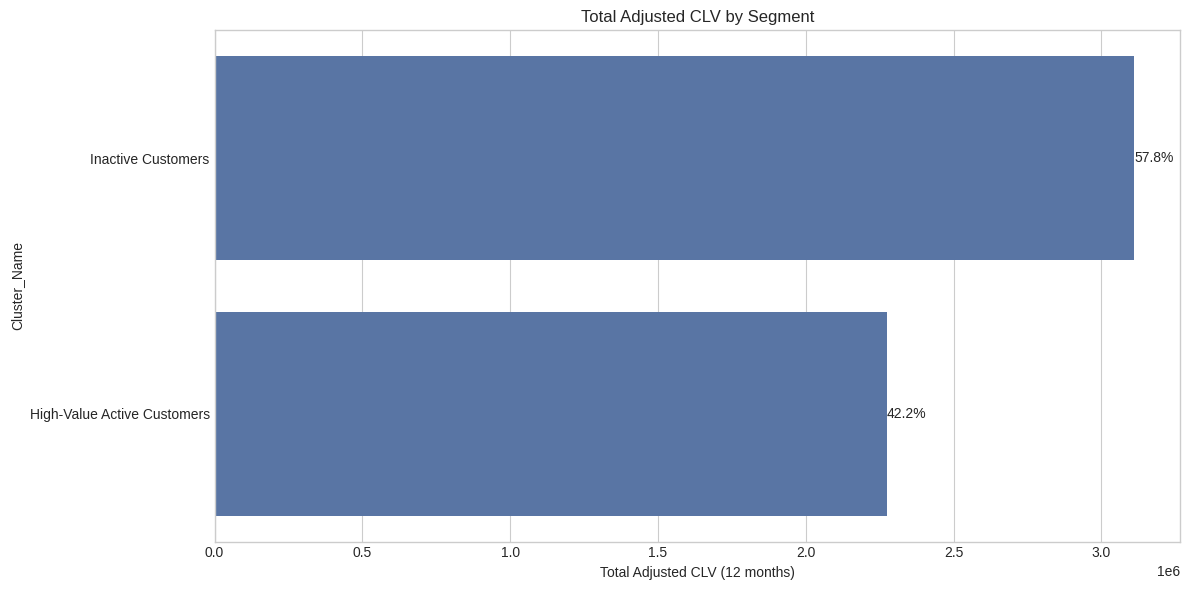

In [22]:
# Visualize CLV by segment
plt.figure(figsize=(12, 6))
sns.barplot(x='Avg_CLV', y='Cluster_Name', data=clv_by_segment)
plt.title('Average Customer Lifetime Value by Segment')
plt.xlabel('Average CLV (12 months)')
plt.tight_layout()
plt.show()

# Visualize total CLV by segment
plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Adjusted_CLV', y='Cluster_Name', data=clv_by_segment)
plt.title('Total Adjusted CLV by Segment')
plt.xlabel('Total Adjusted CLV (12 months)')
for i, row in enumerate(clv_by_segment.itertuples()):
    plt.text(row.Total_Adjusted_CLV + 1000, i, f'{row.Segment_Value_Percentage:.1f}%', va='center')
plt.tight_layout()
plt.show()


##**Identifying highest value customers**


Top 10 Customers by Adjusted CLV:


,Customer ID,CLV_12_months,ChurnProbability,Adjusted_CLV,Cluster_Name
1092,14646.0,125518.572731,1.234575e-14,125518.572731,High-Value Active Customers
818,14096.0,92817.641437,2.380200e-09,92817.641216,High-Value Active Customers
1224,14911.0,91630.256374,2.011736e-17,91630.256374,High-Value Active Customers
33,12415.0,56529.200351,5.242360e-06,56528.904005,High-Value Active Customers
2398,17511.0,55348.726890,5.319355e-08,55348.723946,High-Value Active Customers
2660,18102.0,54103.637415,7.471822e-05,54099.594888,High-Value Active Customers
847,14156.0,53620.979982,2.580331e-07,53620.966146,High-Value Active Customers
1405,15311.0,41532.550116,6.963869e-09,41532.549826,High-Value Active Customers
354,13089.0,41290.316829,1.326046e-07,41290.311353,High-Value Active Customers
816,14088.0,40172.937605,1.991452e-04,40164.937358,High-Value Active Customers


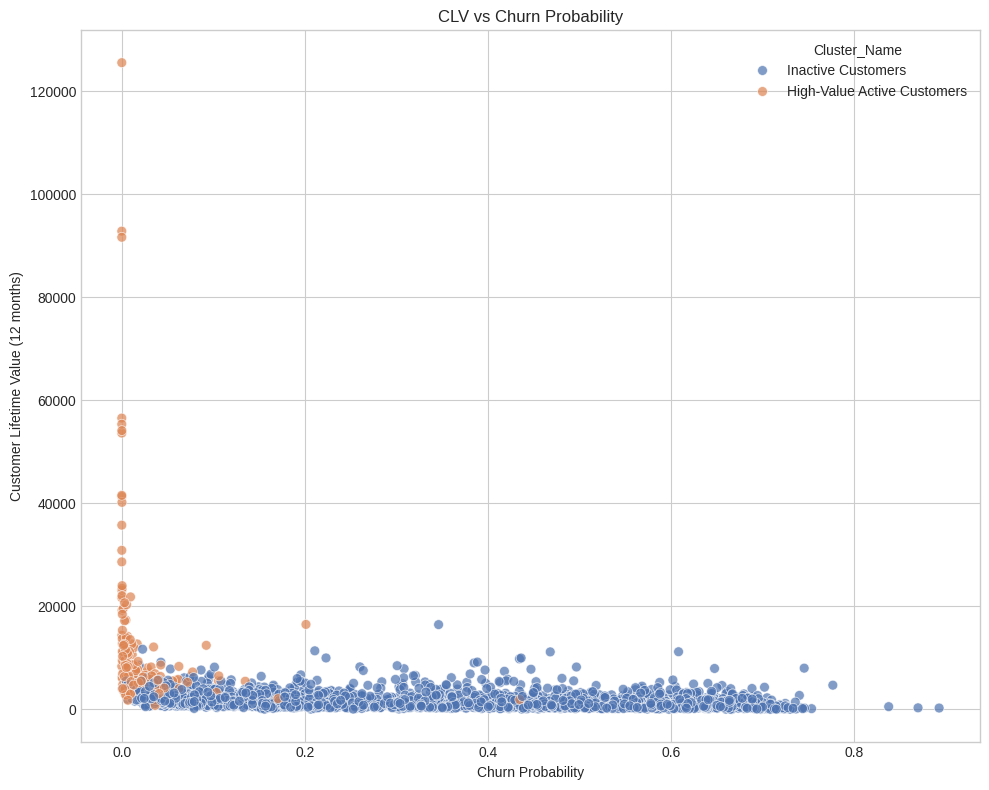

In [24]:
# Identify highest CLV customers
top_clv_customers = customer_data.sort_values('Adjusted_CLV', ascending=False).head(100)
print("\nTop 10 Customers by Adjusted CLV:")
display(top_clv_customers[['Customer ID', 'CLV_12_months', 'ChurnProbability', 'Adjusted_CLV', 'Cluster_Name']].head(10))

# Analyze CLV vs churn risk
plt.figure(figsize=(10, 8))
sns.scatterplot(x='ChurnProbability', y='CLV_12_months', hue='Cluster_Name',
                data=customer_data, alpha=0.7, s=50)
plt.title('CLV vs Churn Probability')
plt.xlabel('Churn Probability')
plt.ylabel('Customer Lifetime Value (12 months)')
plt.grid(True)
plt.tight_layout()
plt.show()


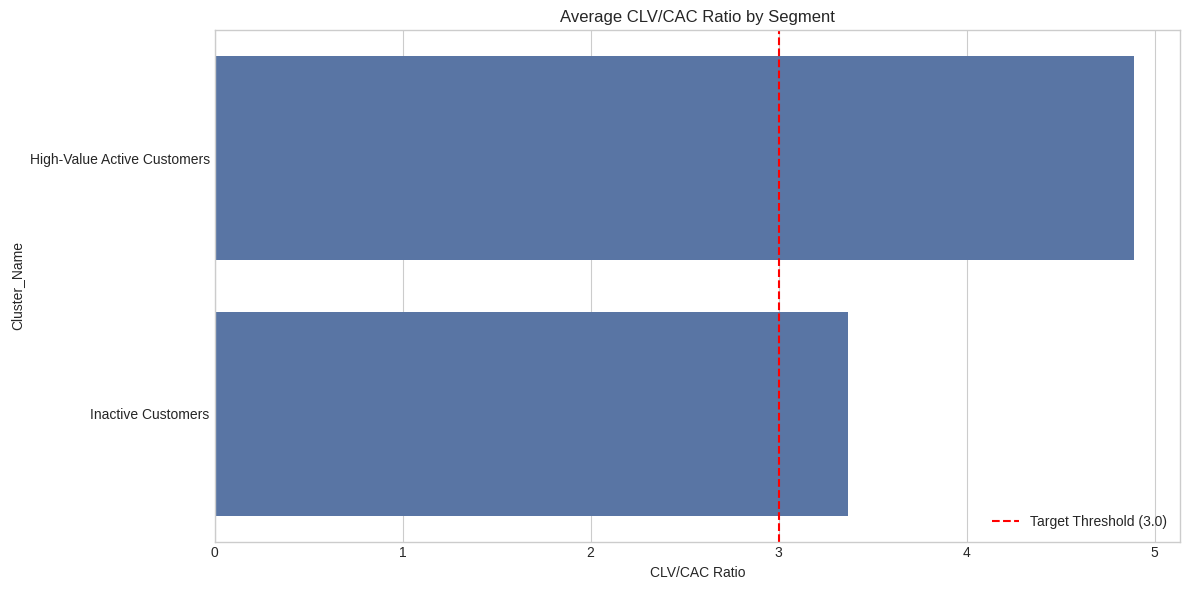

In [25]:
# Calculate CLV-to-CAC ratio (assuming acquisition cost is 20% of first year CLV for demonstration)
# In a real business scenario, you would use actual acquisition cost data
customer_data['Estimated_CAC'] = customer_data['CLV_12_months'] * 0.2
customer_data['CLV_CAC_Ratio'] = customer_data['Adjusted_CLV'] / customer_data['Estimated_CAC']

# Analyze CLV/CAC ratio by segment
clv_cac_by_segment = customer_data.groupby('Cluster_Name')['CLV_CAC_Ratio'].mean().reset_index()
clv_cac_by_segment = clv_cac_by_segment.sort_values('CLV_CAC_Ratio', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='CLV_CAC_Ratio', y='Cluster_Name', data=clv_cac_by_segment)
plt.title('Average CLV/CAC Ratio by Segment')
plt.xlabel('CLV/CAC Ratio')
plt.axvline(x=3, color='red', linestyle='--', label='Target Threshold (3.0)')
plt.legend()
plt.tight_layout()
plt.show()

##**Saving the CLV data**

In [26]:
# Save the CLV data

import os
os.makedirs('data/processed', exist_ok=True)
customer_data.to_csv('data/processed/customer_lifetime_value.csv', index=False)
files.download('data/processed/customer_lifetime_value.csv')
print("\nCustomer Lifetime Value data saved to 'data/processed/customer_lifetime_value.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Customer Lifetime Value data saved to 'data/processed/customer_lifetime_value.csv'


In [27]:
# Key insights from CLV analysis
print("\n=== KEY INSIGHTS FROM CLV ANALYSIS ===")
print(f"1. Average 12-month CLV: ${customer_data['CLV_12_months'].mean():.2f}")
print(f"2. Total 12-month CLV: ${customer_data['CLV_12_months'].sum():.2f}")
print(f"3. Adjusted for churn, total future value: ${customer_data['Adjusted_CLV'].sum():.2f}")
print(f"4. Highest value segment: {clv_by_segment.iloc[0]['Cluster_Name']} (${clv_by_segment.iloc[0]['Avg_CLV']:.2f} avg CLV)")
print(f"5. Segment with best CLV/CAC ratio: {clv_cac_by_segment.iloc[0]['Cluster_Name']} ({clv_cac_by_segment.iloc[0]['CLV_CAC_Ratio']:.2f})")
print(f"6. Number of high-value customers (CLV > ${customer_data['CLV_12_months'].quantile(0.9):.2f}): {(customer_data['CLV_12_months'] > customer_data['CLV_12_months'].quantile(0.9)).sum()}")


=== KEY INSIGHTS FROM CLV ANALYSIS ===
1. Average 12-month CLV: $2398.24
2. Total 12-month CLV: $6580760.36
3. Adjusted for churn, total future value: $5384564.50
4. Highest value segment: Inactive Customers ($1704.23 avg CLV)
5. Segment with best CLV/CAC ratio: High-Value Active Customers (4.89)
6. Number of high-value customers (CLV > $4572.02): 275
